# **TP3 - Data Preprocessing**

<b>Exploratory Data Analysis & Unsuperivsed Learning </b><br>
**Course: Dr. Sothea HAS** <br> 
**TP: Mr. Sreyvi UANN**

-------

## **1. Missing Values**

[Cardiovascular diseases (CVDs)](https://www.who.int/health-topics/cardiovascular-diseases#tab=tab_1) are the leading cause of death globally, taking an estimated 17.9 million lives each year ([WHO](https://www.who.int/health-topics/cardiovascular-diseases#tab=tab_1)). CVDs are a group of disorders of the heart and blood vessels and include coronary heart disease, cerebrovascular disease, rheumatic heart disease and other conditions. More than four out of five CVD deaths are due to heart attacks and strokes, and one third of these deaths occur prematurely in people under 70 years of age. Heart failure is a common event caused by CVDs and this dataset contains 11 features that can be used to predict a possible heart disease.

The following `Heart Failure` dataset is obtained by combining 5 different heart disease datasets, consisting of 11 features and a target column indicating heart disease status of the patients. We will build a classification model to predict the heart status of the patients.

We will explore [Kaggle Heart Failure Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction). Load the dataset into the environment.

**a.** Import this data and name it `data`.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('heart.csv')
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [18]:
len(data)

918

## Attribute Information
- Age: age of the patient [years]
- Sex: sex of the patient [M: Male, F: Female]
- ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
- RestingBP: resting blood pressure [mm Hg]
- Cholesterol: serum cholesterol [mm/dl]
- FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
- RestingECG: resting electrocardiogram results [Normal: Normal, ST: having S T-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: - showing probable or definite left ventricular hypertrophy by Estes' criteria]
- MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
- ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
- Oldpeak: oldpeak = ST [Numeric value measured in depression]
- ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
- HeartDisease: output class [1: heart disease, 0: Normal]


**b.** What's the dimension of the dataset? Check and modify if there are any columns with inappropriate data type.

In [19]:
print(f"Dimension of dataset: {data.shape}\n")

print(data.dtypes)

Dimension of dataset: (918, 12)

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


In [20]:
data['FastingBS'] = data['FastingBS'].astype('object')
data['HeartDisease'] = data['HeartDisease'].astype('object')

**c.** Compute descriptive statistics of each column. 

- Do you observe anything strange? 

- Handle what seems to be the problem properly.

In [21]:
qual_col = data.select_dtypes(include="object").columns
quan_col = data.select_dtypes(include="number").columns

for qc in qual_col:
    print(f"{data[qc].value_counts(normalize=True)} \n")

Sex
M    0.78976
F    0.21024
Name: proportion, dtype: float64 

ChestPainType
ASY    0.540305
NAP    0.221133
ATA    0.188453
TA     0.050109
Name: proportion, dtype: float64 

FastingBS
0    0.766885
1    0.233115
Name: proportion, dtype: float64 

RestingECG
Normal    0.601307
LVH       0.204793
ST        0.193900
Name: proportion, dtype: float64 

ExerciseAngina
N    0.595861
Y    0.404139
Name: proportion, dtype: float64 

ST_Slope
Flat    0.501089
Up      0.430283
Down    0.068627
Name: proportion, dtype: float64 

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64 



- Sex is skew to Male

In [22]:
data.describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368,0.887364
std,9.432617,18.514154,109.384145,25.460334,1.066570
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


- restingbp and cholesterol min value is 0 which is invalid

In [23]:
data.query("RestingBP == 0")
data = data.query('RestingBP > 0') # drop the one row with RestingBP = 0

In [24]:
print(f"Shape of Data with cholesterol = 0: {data[data['Cholesterol'] == 0].shape}")

Shape of Data with cholesterol = 0: (171, 12)


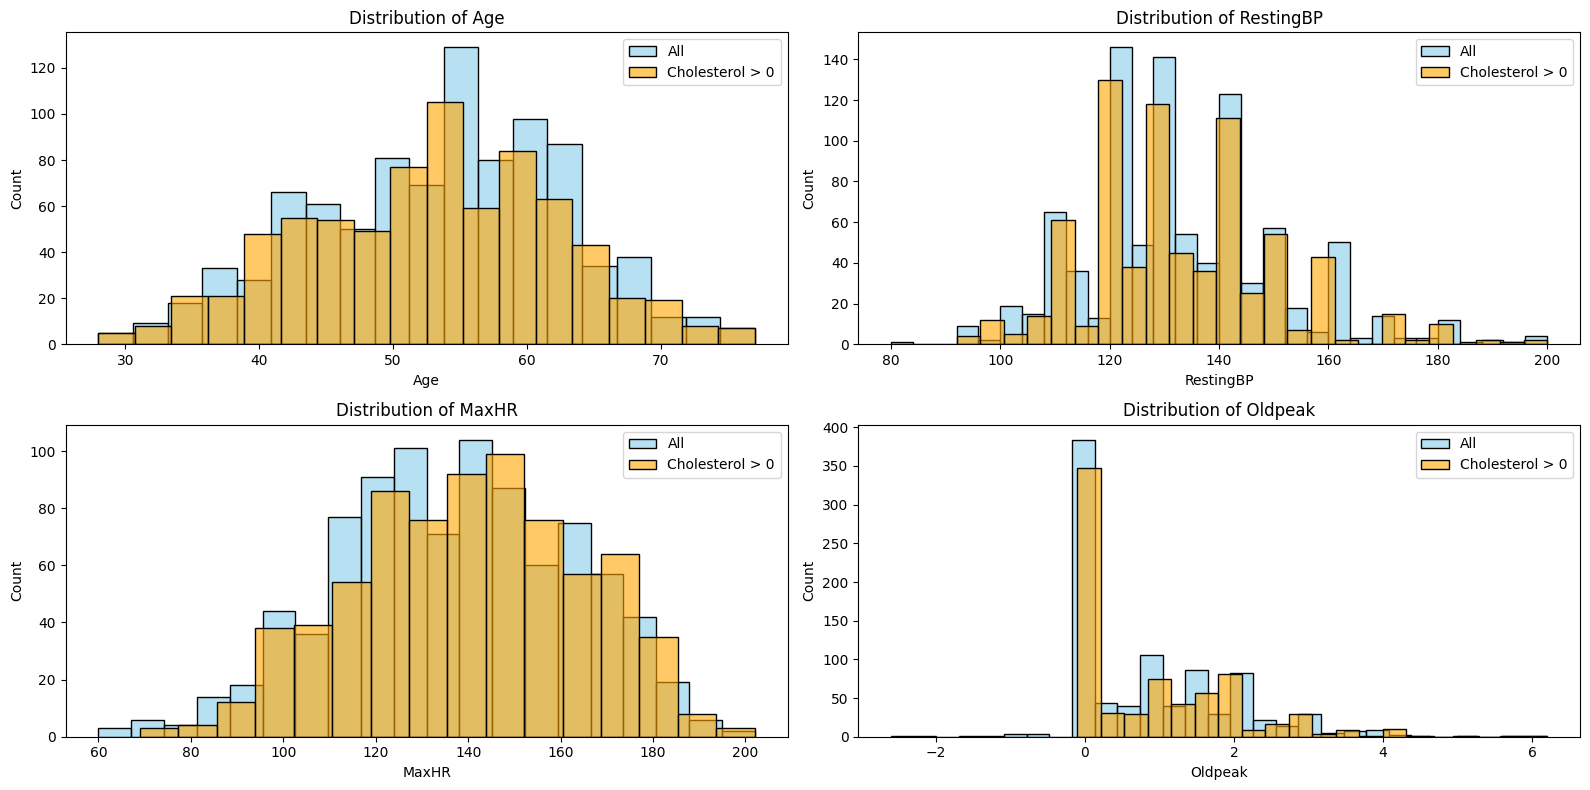

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()
plot_cols = [col for col in quan_col if col != "Cholesterol"]

for i, qc in enumerate(plot_cols):
    # Plot all data
    if qc != "Cholesterol":
        sns.histplot(data=data, x=qc, ax=axes[i], color='skyblue', label='All', kde=False, alpha=0.6)
        # Plot filtered data (e.g., Cholesterol > 0)
        sns.histplot(data=data.query("Cholesterol > 0"), x=qc, ax=axes[i], color='orange', label='Cholesterol > 0', kde=False, alpha=0.6)
        
        axes[i].set_title(f"Distribution of {qc}")
        axes[i].legend()

plt.tight_layout()
plt.show()

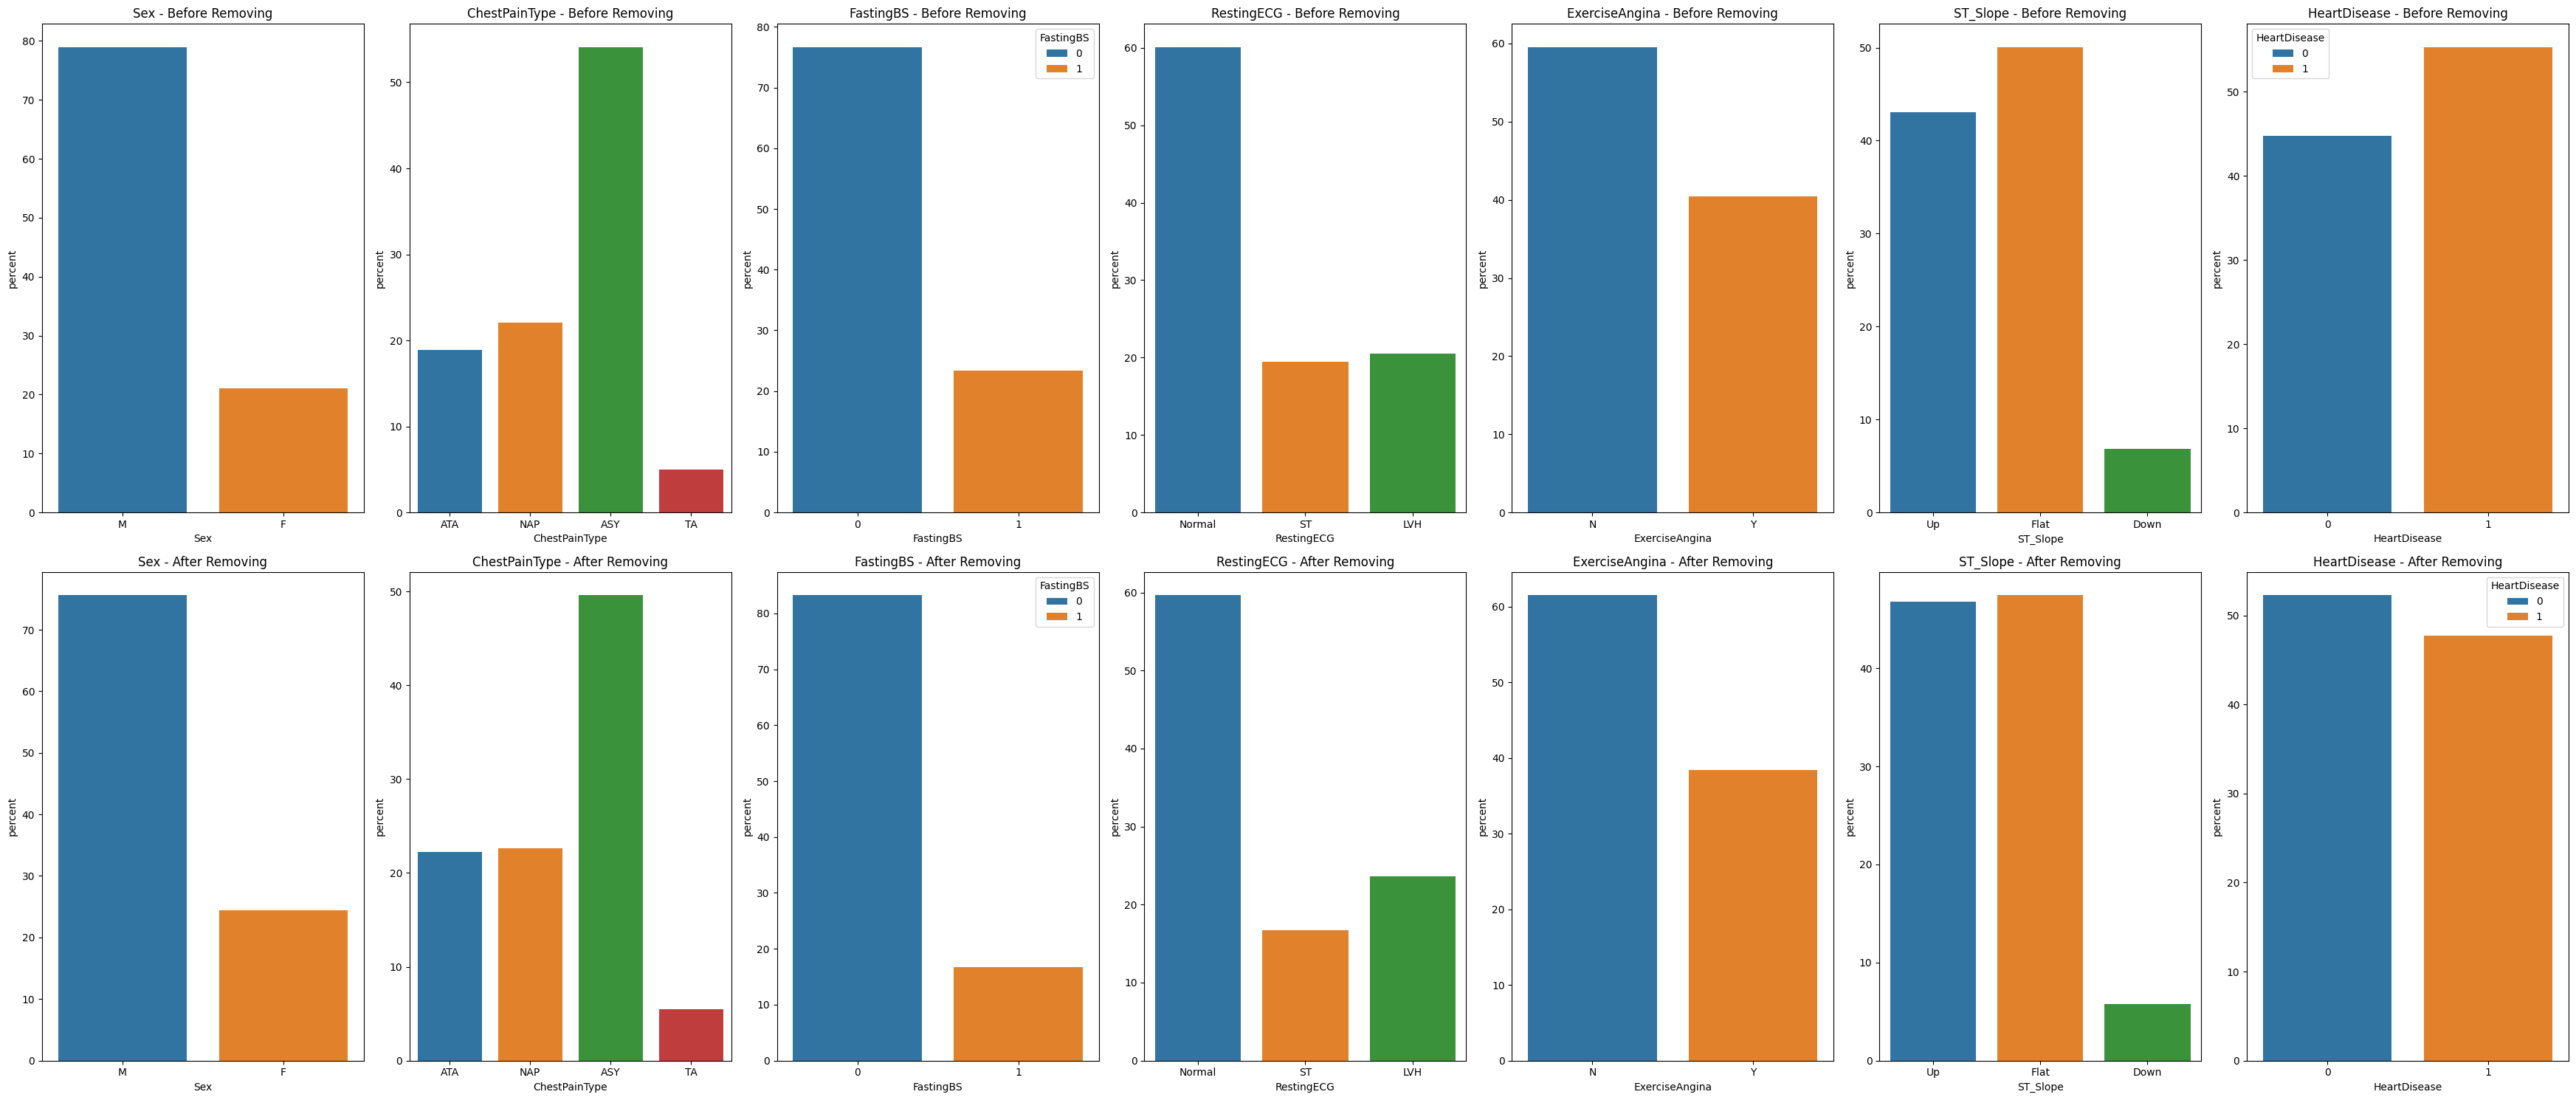

In [26]:
num_cols = len(qual_col)
fig, axes = plt.subplots(2, num_cols, figsize=(5*num_cols, 15))  

for i, col in enumerate(qual_col):
    # Before removing
    sns.countplot(data=data, x=col, stat="percent", ax=axes[0, i], hue=col)
    axes[0, i].set_title(f"{col} - Before Removing")
    
    # After removing Cholesterol <= 0
    sns.countplot(data=data.query("Cholesterol > 0"), x=col, stat="percent", ax=axes[1, i], hue=col)
    axes[1, i].set_title(f"{col} - After Removing")

plt.tight_layout()
plt.show()

In [27]:
# check connection between oldpeak and cholesterol

pcorr = data[["Oldpeak", "Cholesterol"]].corr()
scorr = data[["Oldpeak", "Cholesterol"]].corr(method="spearman")

display(
    pcorr
    .style
    .background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
    .set_caption("Pearson Correlation")
    .format('{:.3f}')
)

display(
    scorr
    .style
    .background_gradient(cmap='YlGnBu', vmin=-1, vmax=1)
    .set_caption("Spearman Correlation")
    .format('{:.3f}')
)

,Oldpeak,Cholesterol
Oldpeak,1.000,0.051
Cholesterol,0.051,1.000


,Oldpeak,Cholesterol
Oldpeak,1.000,0.053
Cholesterol,0.053,1.000


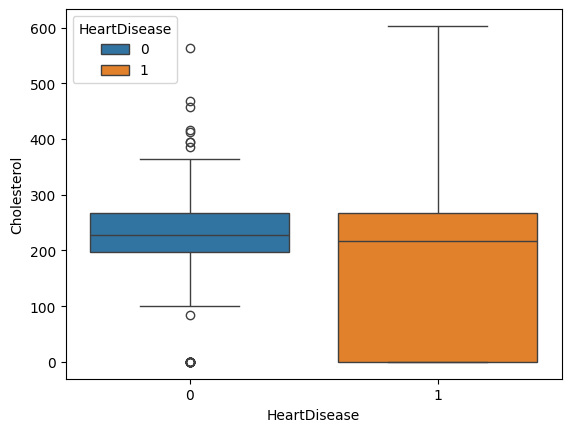

In [28]:
# check connection between heartdisease and cholesterol
sns.boxplot(data=data, x="HeartDisease", y="Cholesterol", hue="HeartDisease")
plt.show()

In [29]:
data.groupby("HeartDisease")["Cholesterol"].mean()

HeartDisease
0    227.121951
1    176.287968
Name: Cholesterol, dtype: float64

In [30]:
# replace 0 with nan
data['Cholesterol'] = data['Cholesterol'].replace(0, np.nan)

# fill mean group by heartdisease
data['Cholesterol'] = data.groupby('HeartDisease')['Cholesterol'].transform(lambda x: x.fillna(x.mean()))

**d.** Are there any potential outliers? Take a note for later improvement in your analysis. 

- Are there any duplicated observations? Handle them properly.

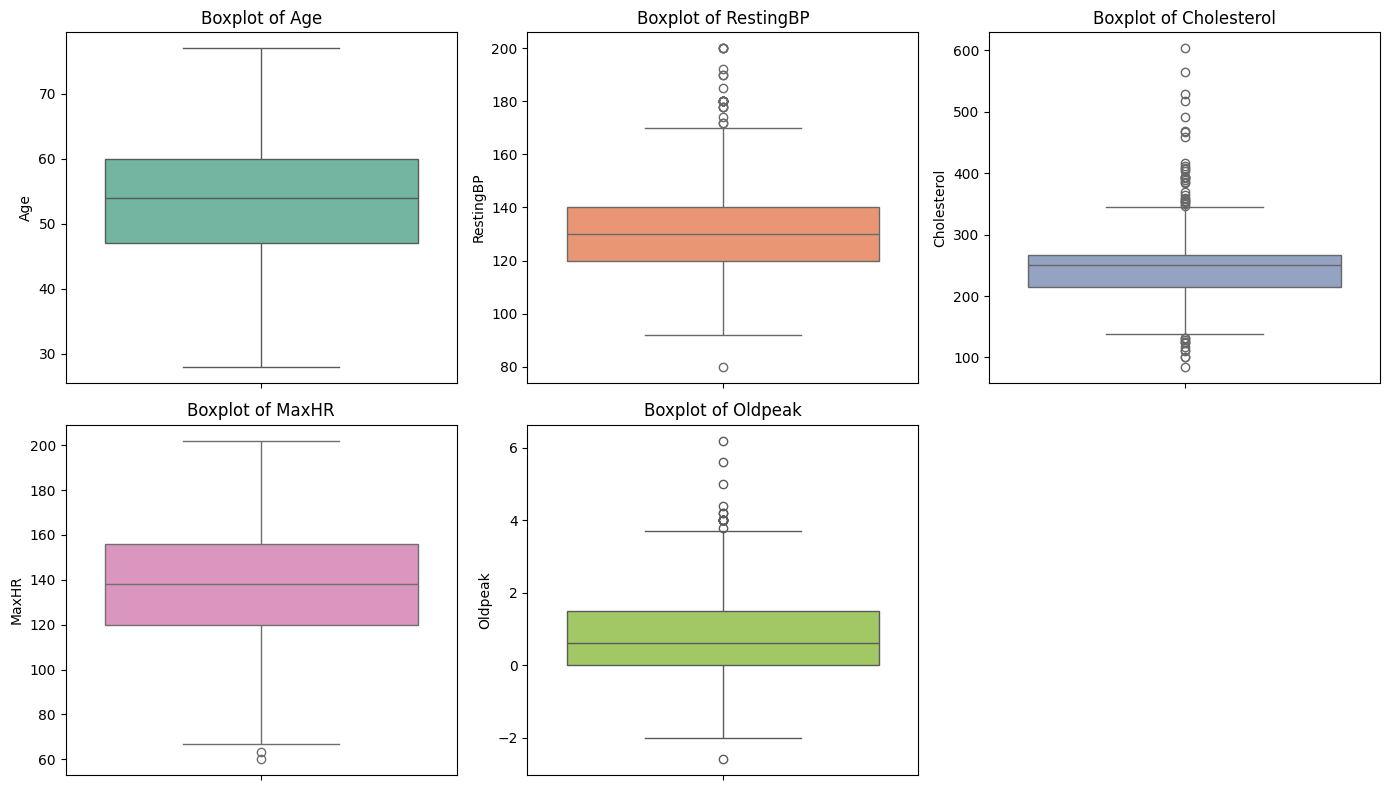

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
palette = []
palette = sns.color_palette("Set2", n_colors=len(quan_col))

for i, col in enumerate(quan_col):
    sns.boxplot(data=data, y=col, ax=axes[i], color=palette[i])
    axes[i].set_title(f"Boxplot of {col}")

for j in range(len(quan_col), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

In [32]:
print(f"There are {int(data.duplicated().sum())} duplicated values in the dataset.")

There are 0 duplicated values in the dataset.


What I have learned:

In scenario: data column X is invalid (out of range, negative, etc)
- if X is small percentage > drop it
- if X is high percentage, 
    - Study it by comparing the distribution of other columns before and after dropping X. 
    - Check correlation between X and affected columns
        - for qual affected -> fill mean of X of qual's class
        - for quan affected -> fit a model then impute
        - if no correlation can fill global mean of X

**Note**: If dropping change the distribution, avoid doing it, choose imputation method instead.



Question: Suppose the outliers are true and we are not training a model, 
- what do we do with it? Do we keep it or remove it?
- Do we apply the same method as missing values?
        

## 2. Outliers & high leverage data

In an unsupervised framework, outliers are data points that significantly deviate from the majority of observations. In a supervised framework, inputs with extreme values (but not their target) are known as high leverage points. Both outliers and high leverage points may obscure (but not always) the true underlying patterns in the data, often complicating analysis and leading to potential inaccuracies. We will start hunting outliers and high leverage points using [`Abalone` dataset](https://www.kaggle.com/datasets/rodolfomendes/abalone-dataset).

**a.** Download and import the dataset.

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("abalone.csv")
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


**b.** Compute and visualize both correlation matrices. Provide your first impression on the correlation matrices.

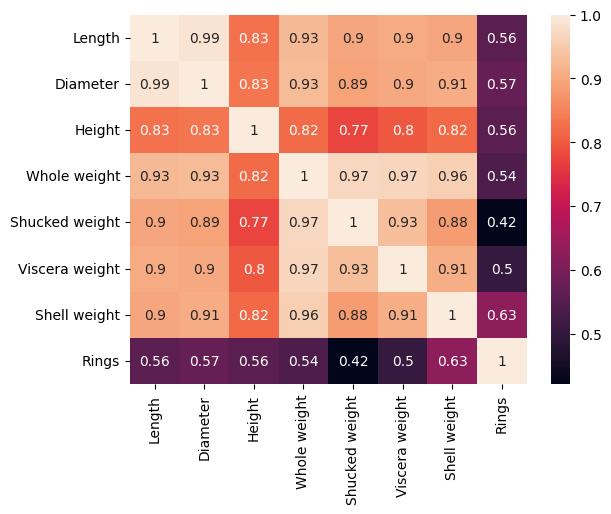

In [9]:
numeric_df = df.drop(columns=['Sex'])
ax = sns.heatmap(numeric_df.corr(), annot=True)

**c.** Study the relation between `Type` and the most interesting variable (target) `Rings`.

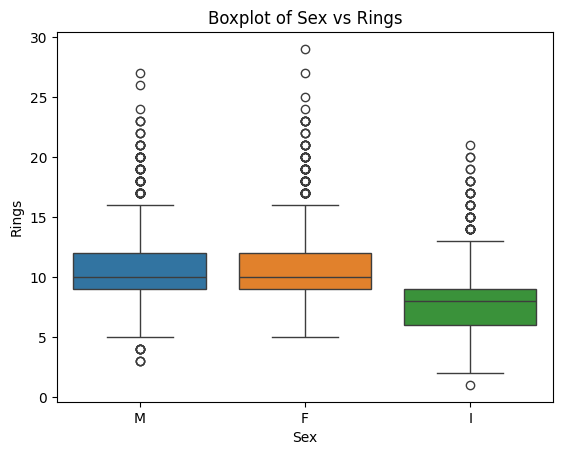

In [10]:
sns.boxplot(data=df, x="Sex", y="Rings", hue="Sex")
plt.title("Boxplot of Sex vs Rings")
plt.show()

**d.** Insepct outliers and high leverage data points (considering `Rings` as the target) in the dataset. You might be interested in the following interesting lessons from STAT 501:
- [Using Leverages to Help Identify Extreme x Values, STAT 501](https://online.stat.psu.edu/stat501/lesson/11/11.2)
- [Identifying Outliers (Unusual y Values), STAT 501](https://online.stat.psu.edu/stat501/lesson/11/11.3)

In [11]:
X = df.drop(columns=['Rings', 'Sex'])
y = df['Rings']

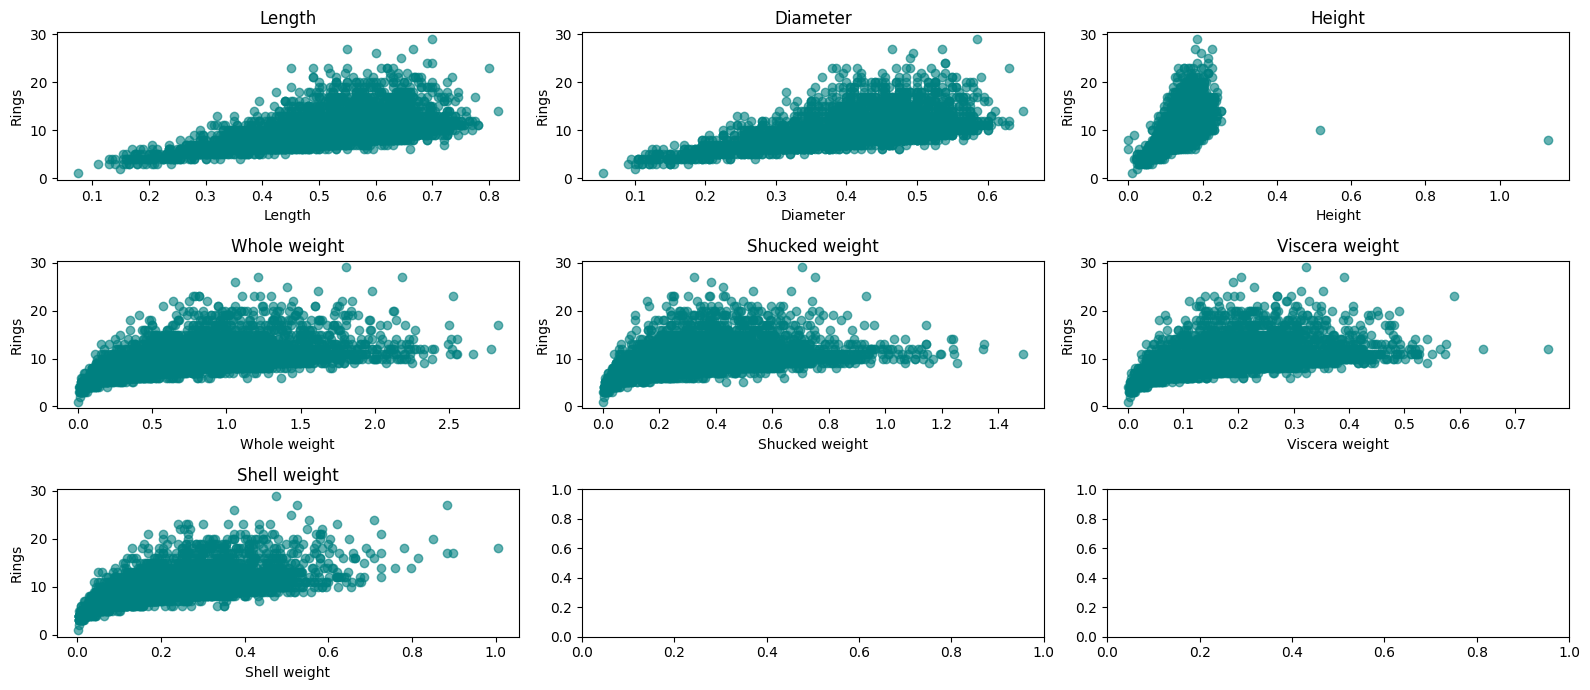

In [12]:
columns = X.columns
fig, axes = plt.subplots(3, 3, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(columns):
    axes[i].scatter(df[col], y, alpha=0.6, color='teal')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Rings')

plt.tight_layout()
plt.show()

**e.** Once again, study the correlation matrices of the data after removing outliers and high leverage data points. Conclude.

In [13]:
import statsmodels.api as sm

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
influence = model.get_influence()
df['studentized_resid'] = influence.resid_studentized_external
df['leverage'] = influence.hat_matrix_diag

In [14]:
n = X.shape[0]
p = X.shape[1] - 1

leverage_cutoff = 2 * (p + 1) / n
cooks_cutoff = 4 / n

from IPython.display import display, Markdown

outliers = df[abs(df['studentized_resid']) > 3]
high_leverage = df[df['leverage'] > leverage_cutoff]

display(Markdown("### Outliers"))
display(outliers)

display(Markdown("### High Leverage Points"))
display(high_leverage)


### Outliers

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,studentized_resid,leverage
6,F,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.330,20,3.022770,0.001955
33,F,0.680,0.550,0.175,1.7980,0.8150,0.3925,0.455,19,3.375672,0.002178
81,M,0.620,0.510,0.175,1.6150,0.5105,0.1920,0.675,12,-3.370543,0.014596
294,M,0.600,0.495,0.195,1.0575,0.3840,0.1900,0.375,26,5.286195,0.002266
310,F,0.630,0.485,0.190,1.2435,0.4635,0.3055,0.390,21,3.527389,0.001531
...,...,...,...,...,...,...,...,...,...,...,...
3340,I,0.540,0.435,0.145,0.9700,0.4285,0.2200,0.264,17,3.127442,0.000519
3865,M,0.525,0.395,0.165,0.7820,0.2850,0.1405,0.285,19,3.197220,0.001531
3914,I,0.520,0.390,0.140,0.7325,0.2415,0.1440,0.260,19,3.278974,0.001164
3924,F,0.500,0.400,0.165,0.7105,0.2700,0.1455,0.225,20,4.019076,0.000947


### High Leverage Points

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,studentized_resid,leverage
31,F,0.680,0.560,0.165,1.6390,0.6055,0.2805,0.4600,15,-0.205535,0.006018
36,F,0.540,0.475,0.155,1.2170,0.5305,0.3075,0.3400,16,2.378228,0.004256
46,M,0.470,0.370,0.120,0.5795,0.2930,0.2270,0.1400,9,0.896976,0.003950
67,F,0.595,0.495,0.185,1.2850,0.4160,0.2240,0.4850,13,-1.483383,0.003922
81,M,0.620,0.510,0.175,1.6150,0.5105,0.1920,0.6750,12,-3.370543,0.014596
...,...,...,...,...,...,...,...,...,...,...,...
4085,M,0.585,0.510,0.160,1.2180,0.6390,0.2410,0.3000,11,0.758022,0.004330
4089,M,0.610,0.365,0.155,1.0765,0.4880,0.2490,0.2700,9,0.138602,0.012641
4112,F,0.560,0.420,0.180,1.6645,0.7755,0.3500,0.4525,9,-0.452873,0.005003
4145,M,0.670,0.525,0.200,1.7405,0.6205,0.2970,0.6570,11,-2.980359,0.007366


In [15]:
clean_df = df[
    (abs(df['studentized_resid']) <= 3) &
    (df['leverage'] <= leverage_cutoff)
]

In [23]:
clean_df

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,studentized_resid,leverage
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15,2.808623,0.000892
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7,-0.107155,0.000769
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9,-0.832579,0.000725
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10,0.328017,0.001018
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7,0.004717,0.001006
...,...,...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11,0.193864,0.001158
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10,0.127286,0.000900
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9,-0.848695,0.001601
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10,0.172581,0.001034


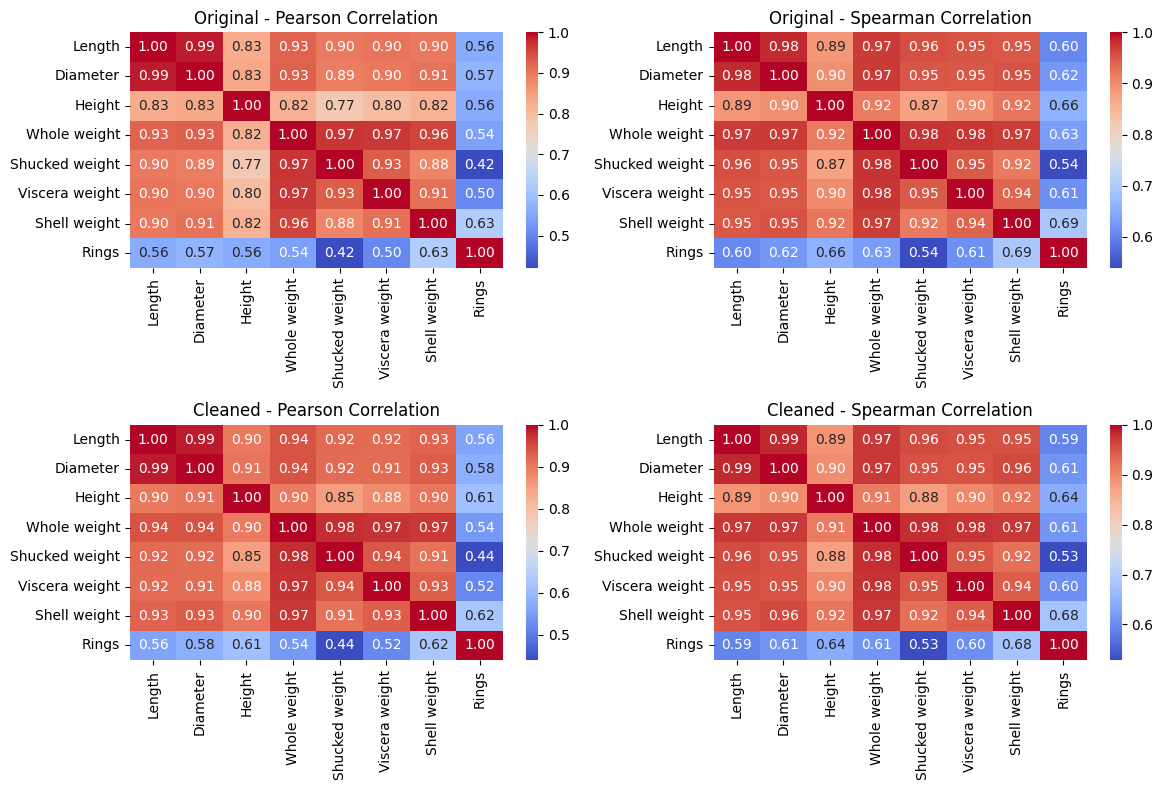

In [26]:
num_clean_df = clean_df.select_dtypes(include='number').drop(columns=['studentized_resid','leverage'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
dfs = [numeric_df, num_clean_df]

methods = ['pearson', 'spearman']
for i, df in enumerate(dfs):
    for j, m in enumerate(methods):
        sns.heatmap(df.corr(method=m), ax=axes[i, j], annot=True, fmt=".2f", cmap="coolwarm")
        axes[i, j].set_title(f"{'Cleaned' if i else 'Original'} - {m.capitalize()} Correlation")

plt.tight_layout()
plt.show()

- High Leverage Points: A point with an extreme value in one or more independent (X) variables compared to other observations.

    > **Example**: Suppose most data points have X between 0–10, but one data point has X = 100.
    That’s a high leverage point, even if its Y fits the pattern.

- Outliers: A point whose dependent variable (Y) value is very different from what the model predicts (large residual).

    > **Example**: A point far away vertically from the regression line.

# Further Readings

- [Outliers & high leverage observations](https://online.stat.psu.edu/stat501/lesson/11/11.1#:~:text=A%20data%20point%20has%20high,is%20particularly%20high%20or%20low.)
- [Using Leverages to Help Identify Extreme x Values, STAT 501](https://online.stat.psu.edu/stat501/lesson/11/11.2)
- [Identifying Outliers (Unusual y Values), STAT 501](https://online.stat.psu.edu/stat501/lesson/11/11.3)
- [Missing data: types, explanation, Imputation](https://www.scribbr.com/statistics/missing-data/)
- [Kaggle: Abalone dataset](https://www.kaggle.com/datasets/rodolfomendes/abalone-dataset)
- [Chapet 3, section 3.3.3 of The Introduction to Statistical Learning](https://www.stat.berkeley.edu/~rabbee/s154/ISLR_First_Printing.pdf)